# Predicting Customer Churn with Leakage-Safe Pipelines

## Project snapshot

| | |
|---|---|
| **Problem** | Identify customers at risk of cancelling so retention teams can prioritize outreach. |
| **Data** | 7,043 Telco Customer Churn records with account, service, contract, and billing attributes. |
| **Method** | One-hot encoding and scaling inside an imbalanced-learn pipeline, with random oversampling confined to each training fold. |
| **Evaluation** | Stratified five-fold cross-validation ranked by ROC-AUC, followed by one untouched 20% holdout evaluation. |
| **Result** | Logistic regression achieved **0.846 mean CV ROC-AUC** and **78.6% churn recall** on the holdout set. |

The emphasis is reliable evaluation under class imbalance: every transformation and resampling step is learned inside the pipeline, preventing validation leakage.


In [1]:
# Core imports
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "portfolio_utils").is_dir():
        REPO_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the repository root containing portfolio_utils")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from portfolio_utils import ARTIFACTS_DIR

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)


## 1. Load the dataset

In [2]:
# If you don't have kagglehub yet, install with:
# !pip install -U kagglehub

import kagglehub

# Download latest version of the dataset from KaggleHub
dataset_dir = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Dataset version:", os.path.basename(dataset_dir))

csv_path = os.path.join(dataset_dir, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_raw = pd.read_csv(csv_path)
df_raw.head()


Dataset version: 1


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Validate and clean the data

In [3]:
df = df_raw.copy()

# Convert TotalCharges to numeric (dataset sometimes has blanks)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# In this dataset, missing TotalCharges typically happens when tenure == 0.
# Filling with 0 is a reasonable default (alternatively: median imputation).
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Drop ID column
df = df.drop(columns=["customerID"])

# Quick sanity checks
print("Shape:", df.shape)
display(df.isna().sum().sort_values(ascending=False).head(10))
df.dtypes


Shape: (7043, 20)


gender              0
SeniorCitizen       0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
dtype: int64

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

## 3. Explore the target and numeric features

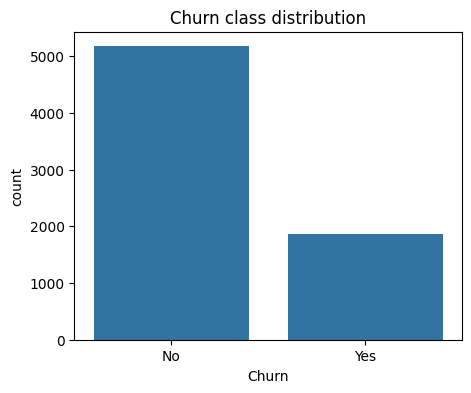

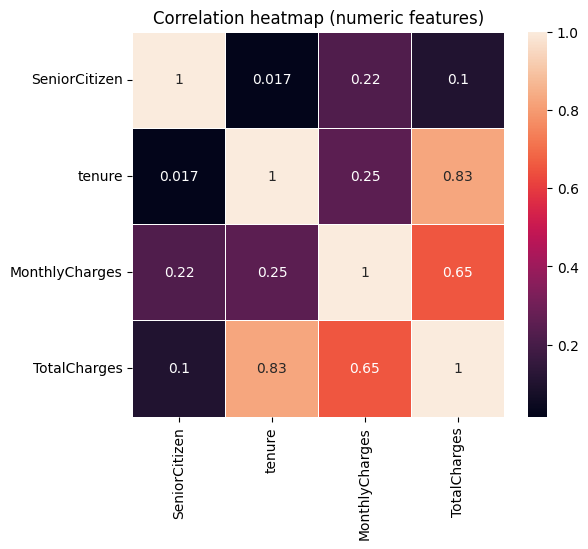

In [4]:
# Target distribution
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Churn")
plt.title("Churn class distribution")
plt.show()

# A quick look at numeric correlations
num_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(6, 5))
sns.heatmap(df[num_cols].corr(), annot=True, linewidths=0.5)
plt.title("Correlation heatmap (numeric features)")
plt.show()


## 4. Create a stratified train/test split

In [5]:
from sklearn.model_selection import train_test_split

TARGET_COL = "Churn"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].map({"No": 0, "Yes": 1}).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3), "Test churn rate:", y_test.mean().round(3))


Train: (5634, 19) Test: (1409, 19)
Train churn rate: 0.265 Test churn rate: 0.265


## 5. Build preprocessing and resampling pipelines

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import StratifiedKFold, cross_validate

# Identify columns
categorical_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=["object", "category", "bool"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

# Preprocessing: scale numeric, one-hot encode categoricals
# - Dense one-hot features keep the small benchmark easy to inspect.
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ],
    remainder="drop",
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def evaluate_model(name, model):
    pipe = ImbPipeline(steps=[
        ("preprocess", preprocess),
        ("resample", RandomOverSampler(random_state=SEED)),
        ("model", model),
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "roc_auc": "roc_auc",
            "f1": "f1",
            "precision": "precision",
            "recall": "recall",
        },
        n_jobs=-1,
        return_train_score=False,
    )
    out = {k: float(np.mean(v)) for k, v in scores.items() if k.startswith("test_")}
    out = {k.replace("test_", ""): v for k, v in out.items()}
    out["model"] = name
    return out, pipe



Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


## 6. Compare models with cross-validation

In [7]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Dummy (most_frequent)": DummyClassifier(strategy="most_frequent", random_state=SEED),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=15),
}

# XGBoost is optional
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1,
    )
except Exception as e:
    print("XGBoost not available (skipping). Install with: pip install xgboost")
    print("Reason:", repr(e))

rows = []
pipes = {}

for name, model in models.items():
    row, pipe = evaluate_model(name, model)
    rows.append(row)
    pipes[name] = pipe

results = pd.DataFrame(rows).set_index("model").sort_values(by="roc_auc", ascending=False)
results


,accuracy,roc_auc,f1,precision,recall
model,,,,,
Logistic Regression,0.747783,0.845744,0.627451,0.515870,0.801338
XGBoost,0.767664,0.837086,0.625541,0.546359,0.731773
Random Forest,0.779022,0.817572,0.578137,0.585574,0.571237
KNN,0.703055,0.804586,0.588077,0.465474,0.798662
Dummy (most_frequent),0.734647,0.500000,0.000000,0.000000,0.000000


## 7. Evaluate the selected model on the holdout set

Best model by CV ROC-AUC: Logistic Regression
              precision    recall  f1-score   support

           0      0.902     0.714     0.797      1035
           1      0.498     0.786     0.610       374

    accuracy                          0.733      1409
   macro avg      0.700     0.750     0.704      1409
weighted avg      0.795     0.733     0.747      1409



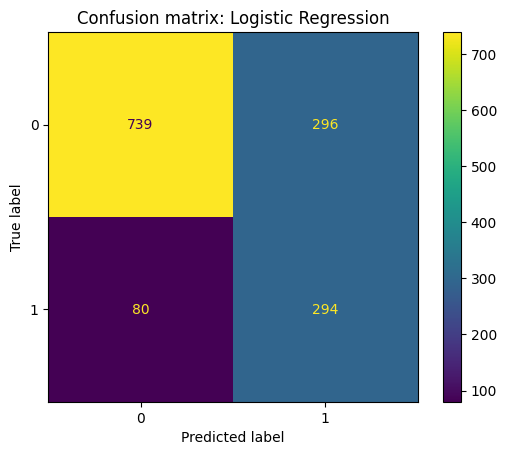

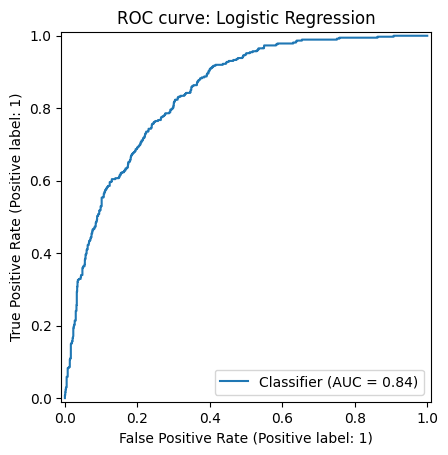

In [8]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
)

best_name = results.index[0]
print("Best model by CV ROC-AUC:", best_name)

best_pipe = pipes[best_name]

# Fit on the full training set
best_pipe.fit(X_train, y_train)

# Predict on test
y_pred = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1] if hasattr(best_pipe, "predict_proba") else None

print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title(f"Confusion matrix: {best_name}")
plt.show()

if y_proba is not None:
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title(f"ROC curve: {best_name}")
    plt.show()


## 8. Tune a Random Forest comparison model

In [9]:
from sklearn.model_selection import GridSearchCV

# Only run this if you want tuning; it can take a while.
rf_pipe = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("resample", RandomOverSampler(random_state=SEED)),
    ("model", RandomForestClassifier(random_state=SEED, n_jobs=-1)),
])

param_grid = {
    "model__n_estimators": [300, 600],
    "model__max_depth": [None, 8, 16],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
}

grid = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

tuned = grid.best_estimator_
y_pred_tuned = tuned.predict(X_test)
print("\nTuned RF test report:")
print(classification_report(y_test, y_pred_tuned, digits=3))


Fitting 5 folds for each of 24 candidates, totalling 120 fits


Best params: {'model__max_depth': 8, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300}
Best CV ROC-AUC: 0.8455876727498138

Tuned RF test report:
              precision    recall  f1-score   support

           0      0.903     0.743     0.815      1035
           1      0.522     0.778     0.625       374

    accuracy                          0.752      1409
   macro avg      0.713     0.761     0.720      1409
weighted avg      0.802     0.752     0.765      1409



## 9. Save the selected pipeline

In [10]:
# This saves the full preprocessing + random oversampling + model pipeline.
# Reload later and call .predict on raw feature columns.

import joblib

MODEL_PATH = ARTIFACTS_DIR / "customer_churn" / "pipeline.joblib"
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_pipe, MODEL_PATH)
print("Saved to:", MODEL_PATH.relative_to(REPO_ROOT))


Saved to: artifacts/customer_churn/pipeline.joblib


## 10. Results

Logistic regression produced the strongest mean cross-validated ROC-AUC (**0.846**) and retained **78.6% recall** for churners on the holdout set. The tuned random forest reached a similar CV ROC-AUC (**0.846**) and a slightly higher holdout churn F1-score (**0.625** versus **0.610**), illustrating the operational trade-off between ranking quality, precision, and recall. The saved artifact remains the logistic-regression pipeline selected by CV ROC-AUC.

## Limitations and next steps

- The holdout contains 1,409 customers from the same source and time context; performance may drift across markets or billing periods.
- Random oversampling duplicates minority examples and does not represent the real production churn rate. Probabilities should be calibrated before they drive interventions.
- Model selection is based on predictive metrics, not the cost of a missed churner versus an unnecessary retention offer.

**Next steps:** validate on an out-of-time cohort, calibrate probabilities, select a decision threshold from retention economics, and add feature-attribution monitoring for deployed predictions.
